# Student Mental Health Analysis Dashboard
**Problem Statement:** Mental health issues among university students — including stress, anxiety, and depression — are rising globally. This project analyzes survey data of 7,037 students to identify key factors affecting mental health, uncover patterns across gender, course, lifestyle habits, and academic load, and present actionable insights through an interactive dashboard.  

**Dataset:** Students Mental Health Survey (Dirty Version) — Kaggle  
**Tool:** Python — pandas, numpy, matplotlib, seaborn, scipy, panel, hvplot

## Step 0 — Install Libraries (run once if needed)

In [1]:
#!pip install hvplot
#!pip install panel

## Step 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import panel as pn
pn.extension('tabulator')
import hvplot.pandas
import warnings
warnings.filterwarnings('ignore')

# Set style — same as teacher's reference notebook
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print('All libraries imported successfully.')

All libraries imported successfully.


## Step 2 — Load Dataset

In [3]:
df = pd.read_csv('students_mental_health_survey_dirty.csv')

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head()

Shape: (7037, 20)
Rows: 7,037  |  Columns: 20


,Age,Course,Gender,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Financial_Stress,Extracurricular_Involvement,Semester_Credit_Load,Residence_Type
0,25.0,Others,Male,3.56,3,3,2,Good,Moderate,Good,Moderate,Married,Never,Never,No,No,2.0,Moderate,17,On-Campus
1,24.0,Engineering,Female,2.44,0,3,0,Average,Low,Average,Low,Single,NaN,Occasionally,No,No,3.0,Low,27,On-Campus
2,19.0,Business,Female,3.74,4,0,3,Good,NaN,Average,Moderate,In a Relationship,Never,Occasionally,No,No,4.0,High,15,On-Campus
3,19.0,Computer Science,Male,3.65,2,1,0,Average,Low,Average,Moderate,Single,NaN,Never,No,No,4.0,Moderate,20,Off-Campus
4,18.0,Business,Male,3.40,3,3,4,Good,Low,Average,High,Married,NaN,Never,No,Yes,0.0,High,23,On-Campus


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7037 entries, 0 to 7036
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          6826 non-null   float64
 1   Course                       7037 non-null   object 
 2   Gender                       7037 non-null   object 
 3   CGPA                         6602 non-null   float64
 4   Stress_Level                 7037 non-null   int64  
 5   Depression_Score             7037 non-null   int64  
 6   Anxiety_Score                7037 non-null   int64  
 7   Sleep_Quality                6688 non-null   object 
 8   Physical_Activity            6757 non-null   object 
 9   Diet_Quality                 6757 non-null   object 
 10  Social_Support               6685 non-null   object 
 11  Relationship_Status          6685 non-null   object 
 12  Substance_Use                6457 non-null   object 
 13  Counseling_Service

## Step 3 — Check Missing Values

In [5]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values per column:
Age                            211
Course                           0
Gender                           0
CGPA                           435
Stress_Level                     0
Depression_Score                 0
Anxiety_Score                    0
Sleep_Quality                  349
Physical_Activity              280
Diet_Quality                   280
Social_Support                 352
Relationship_Status            352
Substance_Use                  580
Counseling_Service_Use         210
Family_History                 210
Chronic_Illness                  0
Financial_Stress               280
Extracurricular_Involvement    280
Semester_Credit_Load             0
Residence_Type                   0
dtype: int64

Total missing values: 3819


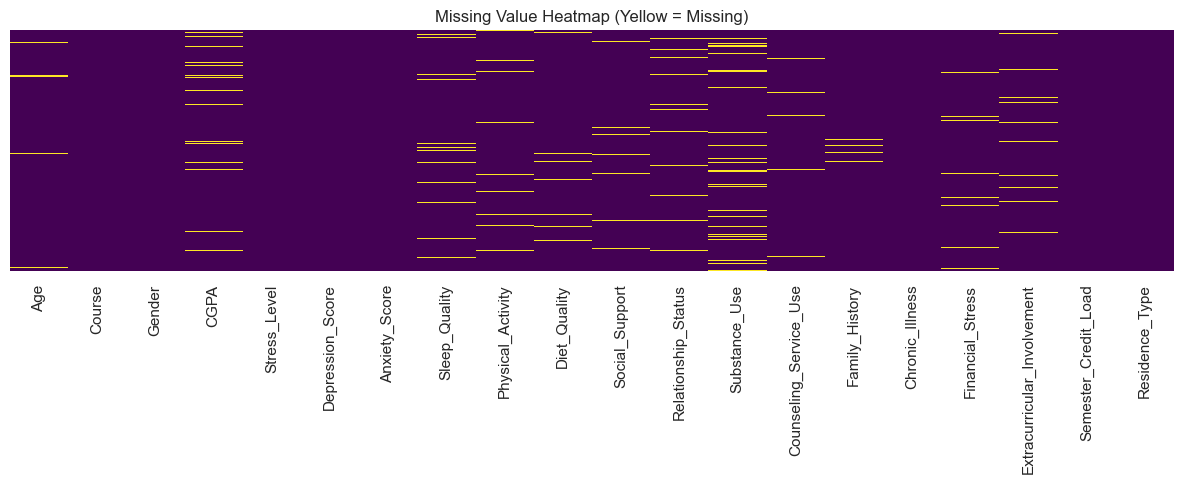

In [6]:
# Visualize missing values as heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap (Yellow = Missing)')
plt.tight_layout()
plt.show()

## Step 4 — Data Cleaning
This dataset is intentionally dirty. We need to fix:
1. Inconsistent text (Male/male/M → Male)
2. Extra whitespace in values
3. Impossible values (Age=5, CGPA=-0.96, negative Stress/Anxiety)
4. Missing values
5. Outlier values in Financial_Stress

In [7]:
# ---- FIX 1: Standardize Gender ----
print('Gender before cleaning:', df['Gender'].unique())
df['Gender'] = df['Gender'].str.strip().str.title()
df['Gender'] = df['Gender'].replace({'M': 'Male', 'F': 'Female'})
print('Gender after cleaning:', df['Gender'].unique())

Gender before cleaning: ['Male' 'Female' 'M' 'male' 'FEMALE']
Gender after cleaning: ['Male' 'Female']


In [8]:
# ---- FIX 2: Standardize Course ----
print('Course before cleaning:', df['Course'].unique())
df['Course'] = df['Course'].str.strip().str.title()
df['Course'] = df['Course'].replace({
    'Cs': 'Computer Science',
    'Business': 'Business',
    'Engineering': 'Engineering'
})
print('Course after cleaning:', df['Course'].unique())

Course before cleaning: ['Others' 'Engineering' 'Business' 'Computer Science' 'Medical' 'Law' 'CS'
 'BUSINESS' 'engineering']
Course after cleaning: ['Others' 'Engineering' 'Business' 'Computer Science' 'Medical' 'Law']


In [9]:
# ---- FIX 3: Standardize Sleep_Quality ----
print('Sleep_Quality before:', df['Sleep_Quality'].dropna().unique())
df['Sleep_Quality'] = df['Sleep_Quality'].str.strip().str.title()
df['Sleep_Quality'] = df['Sleep_Quality'].replace({'Avg': 'Average'})
print('Sleep_Quality after:', df['Sleep_Quality'].dropna().unique())

Sleep_Quality before: ['Good' 'Average' 'Poor' 'Avg' 'POOR' 'good']
Sleep_Quality after: ['Good' 'Average' 'Poor']


In [10]:
# ---- FIX 4: Standardize Diet_Quality and Residence_Type (whitespace) ----
df['Diet_Quality'] = df['Diet_Quality'].str.strip().str.title()
df['Residence_Type'] = df['Residence_Type'].str.strip()
print('Diet_Quality after:', df['Diet_Quality'].dropna().unique())
print('Residence_Type after:', df['Residence_Type'].unique())

Diet_Quality after: ['Good' 'Average' 'Poor']
Residence_Type after: ['On-Campus' 'Off-Campus' 'With Family']


In [11]:
# ---- FIX 5: Remove impossible/outlier values ----

print(f'Rows before outlier removal: {len(df)}')

# Age must be 15 to 35 for university students
df = df[(df['Age'] >= 15) & (df['Age'] <= 35)]

# CGPA must be 0 to 4.0
df = df[(df['CGPA'] >= 0) & (df['CGPA'] <= 4.0)]

# Stress_Level must be 0 to 10
df = df[(df['Stress_Level'] >= 0) & (df['Stress_Level'] <= 10)]

# Anxiety_Score must be 0 to 5
df = df[(df['Anxiety_Score'] >= 0) & (df['Anxiety_Score'] <= 5)]

# Financial_Stress must be 0 to 5
df = df[(df['Financial_Stress'] >= 0) & (df['Financial_Stress'] <= 5)]

# Semester_Credit_Load must be 10 to 30
df = df[(df['Semester_Credit_Load'] >= 10) & (df['Semester_Credit_Load'] <= 30)]

print(f'Rows after outlier removal : {len(df)}')
print(f'Removed rows              : {7037 - len(df)}')

Rows before outlier removal: 7037
Rows after outlier removal : 6013
Removed rows              : 1024


In [12]:
# ---- FIX 6: Fill missing values ----
# Numerical — fill with median (same as teacher's reference notebook)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['CGPA'] = df['CGPA'].fillna(df['CGPA'].median())
df['Financial_Stress'] = df['Financial_Stress'].fillna(df['Financial_Stress'].median())

# Categorical — fill with mode
cat_cols = ['Sleep_Quality','Physical_Activity','Diet_Quality','Social_Support',
            'Relationship_Status','Substance_Use','Counseling_Service_Use',
            'Family_History','Extracurricular_Involvement']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Missing values after cleaning:')
print(df.isnull().sum())
print(f'\nFinal dataset shape: {df.shape}')

Missing values after cleaning:
Age                            0
Course                         0
Gender                         0
CGPA                           0
Stress_Level                   0
Depression_Score               0
Anxiety_Score                  0
Sleep_Quality                  0
Physical_Activity              0
Diet_Quality                   0
Social_Support                 0
Relationship_Status            0
Substance_Use                  0
Counseling_Service_Use         0
Family_History                 0
Chronic_Illness                0
Financial_Stress               0
Extracurricular_Involvement    0
Semester_Credit_Load           0
Residence_Type                 0
dtype: int64

Final dataset shape: (6013, 20)


In [13]:
# Reset index after all cleaning
df = df.reset_index(drop=True)
print('Dataset is clean and ready.')
df.head()

Dataset is clean and ready.


,Age,Course,Gender,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Financial_Stress,Extracurricular_Involvement,Semester_Credit_Load,Residence_Type
0,25.0,Others,Male,3.56,3,3,2,Good,Moderate,Good,Moderate,Married,Never,Never,No,No,2.0,Moderate,17,On-Campus
1,24.0,Engineering,Female,2.44,0,3,0,Average,Low,Average,Low,Single,Never,Occasionally,No,No,3.0,Low,27,On-Campus
2,19.0,Business,Female,3.74,4,0,3,Good,Moderate,Average,Moderate,In a Relationship,Never,Occasionally,No,No,4.0,High,15,On-Campus
3,19.0,Computer Science,Male,3.65,2,1,0,Average,Low,Average,Moderate,Single,Never,Never,No,No,4.0,Moderate,20,Off-Campus
4,18.0,Business,Male,3.40,3,3,4,Good,Low,Average,High,Married,Never,Never,No,Yes,0.0,High,23,On-Campus


## Step 5 — Feature Engineering

In [14]:
# 1. Age Group
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[14, 18, 21, 24, 35],
    labels=['15-18', '19-21', '22-24', '25+']
)

# 2. CGPA Category
df['CGPA_Category'] = pd.cut(
    df['CGPA'],
    bins=[0, 2.0, 2.9, 3.5, 4.0],
    labels=['Poor (<2.0)', 'Average (2-2.9)', 'Good (3-3.5)', 'Excellent (3.5+)']
)

# 3. Mental Health Risk Score (sum of stress + depression + anxiety)
df['Mental_Health_Score'] = df['Stress_Level'] + df['Depression_Score'] + df['Anxiety_Score']

# 4. High Risk flag (top 30% mental health score)
threshold = df['Mental_Health_Score'].quantile(0.70)
df['High_Risk'] = (df['Mental_Health_Score'] >= threshold).astype(int)

print('New columns added: Age_Group, CGPA_Category, Mental_Health_Score, High_Risk')
print(f'High Risk students: {df["High_Risk"].sum():,} out of {len(df):,} ({df["High_Risk"].mean()*100:.1f}%)')
df[['Age', 'Age_Group', 'CGPA', 'CGPA_Category', 'Mental_Health_Score', 'High_Risk']].head(10)

New columns added: Age_Group, CGPA_Category, Mental_Health_Score, High_Risk
High Risk students: 2,521 out of 6,013 (41.9%)


,Age,Age_Group,CGPA,CGPA_Category,Mental_Health_Score,High_Risk
0,25.0,25+,3.56,Excellent (3.5+),8,1
1,24.0,22-24,2.44,Average (2-2.9),3,0
2,19.0,19-21,3.74,Excellent (3.5+),7,0
3,19.0,19-21,3.65,Excellent (3.5+),3,0
4,18.0,15-18,3.40,Good (3-3.5),10,1
5,21.0,19-21,3.35,Good (3-3.5),9,1
6,18.0,15-18,3.65,Excellent (3.5+),9,1
7,21.0,19-21,3.40,Good (3-3.5),6,0
8,24.0,22-24,3.80,Excellent (3.5+),6,0
9,19.0,19-21,3.05,Good (3-3.5),7,0


## Step 6 — Basic Statistical Summary

In [15]:
# Basic dataset statistics — same as teacher's reference
print('Basic Statistical Summary:')
print(df.describe())

Basic Statistical Summary:
               Age         CGPA  Stress_Level  Depression_Score  \
count  6013.000000  6013.000000   6013.000000       6013.000000   
mean     22.984700     3.490213      2.428904          2.271412   
std       3.847747     0.288289      1.656499          1.659919   
min      18.000000     2.440000      0.000000          0.000000   
25%      20.000000     3.290000      1.000000          1.000000   
50%      22.000000     3.500000      2.000000          2.000000   
75%      25.000000     3.700000      4.000000          4.000000   
max      35.000000     4.000000     10.000000         11.000000   

       Anxiety_Score  Financial_Stress  Semester_Credit_Load  \
count    6013.000000       6013.000000            6013.00000   
mean        2.302844          2.463995              22.01081   
std         1.625618          1.711253               4.35692   
min         0.000000          0.000000              15.00000   
25%         1.000000          1.000000           

In [16]:
# Detailed stats on key mental health columns
for col in ['Stress_Level', 'Depression_Score', 'Anxiety_Score', 'Mental_Health_Score']:
    print(f'--- {col} ---')
    print(f'  Mean     : {df[col].mean():.2f}')
    print(f'  Median   : {df[col].median():.2f}')
    print(f'  Std Dev  : {df[col].std():.2f}')
    print(f'  Skewness : {df[col].skew():.3f}')
    print(f'  Min/Max  : {df[col].min()} / {df[col].max()}')
    print()

--- Stress_Level ---
  Mean     : 2.43
  Median   : 2.00
  Std Dev  : 1.66
  Skewness : 0.123
  Min/Max  : 0 / 10

--- Depression_Score ---
  Mean     : 2.27
  Median   : 2.00
  Std Dev  : 1.66
  Skewness : 0.310
  Min/Max  : 0 / 11

--- Anxiety_Score ---
  Mean     : 2.30
  Median   : 2.00
  Std Dev  : 1.63
  Skewness : 0.140
  Min/Max  : 0 / 5

--- Mental_Health_Score ---
  Mean     : 7.00
  Median   : 7.00
  Std Dev  : 2.76
  Skewness : 0.149
  Min/Max  : 0 / 18



## Step 7 — Data Visualizations

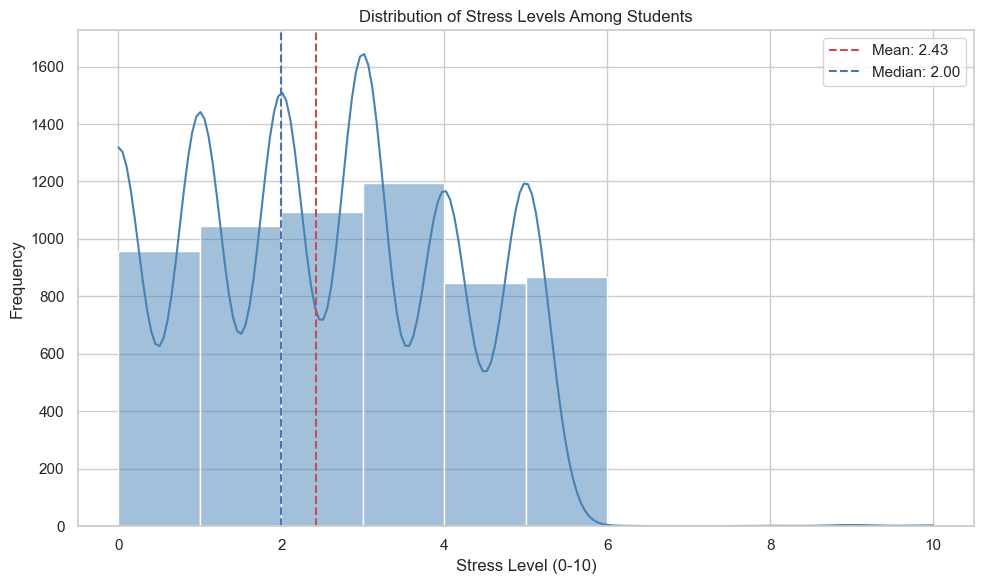

In [17]:
# 1. Histogram of Stress Level — same as teacher's age histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['Stress_Level'], kde=True, bins=10, color='steelblue')
plt.axvline(df['Stress_Level'].mean(), color='r', linestyle='--',
            label=f"Mean: {df['Stress_Level'].mean():.2f}")
plt.axvline(df['Stress_Level'].median(), color='b', linestyle='--',
            label=f"Median: {df['Stress_Level'].median():.2f}")
plt.xlabel('Stress Level (0-10)')
plt.ylabel('Frequency')
plt.title('Distribution of Stress Levels Among Students')
plt.legend()
plt.tight_layout()
plt.show()

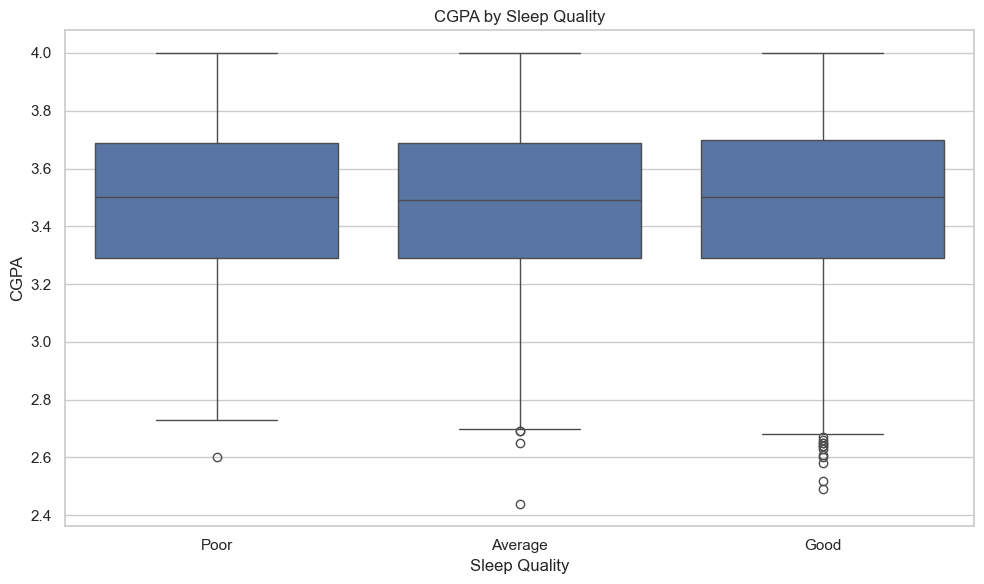

In [18]:
# 2. Boxplot — CGPA by Sleep Quality — same as teacher's cholesterol boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Sleep_Quality', y='CGPA', data=df,
            order=['Poor', 'Average', 'Good'])
plt.title('CGPA by Sleep Quality')
plt.xlabel('Sleep Quality')
plt.ylabel('CGPA')
plt.tight_layout()
plt.show()

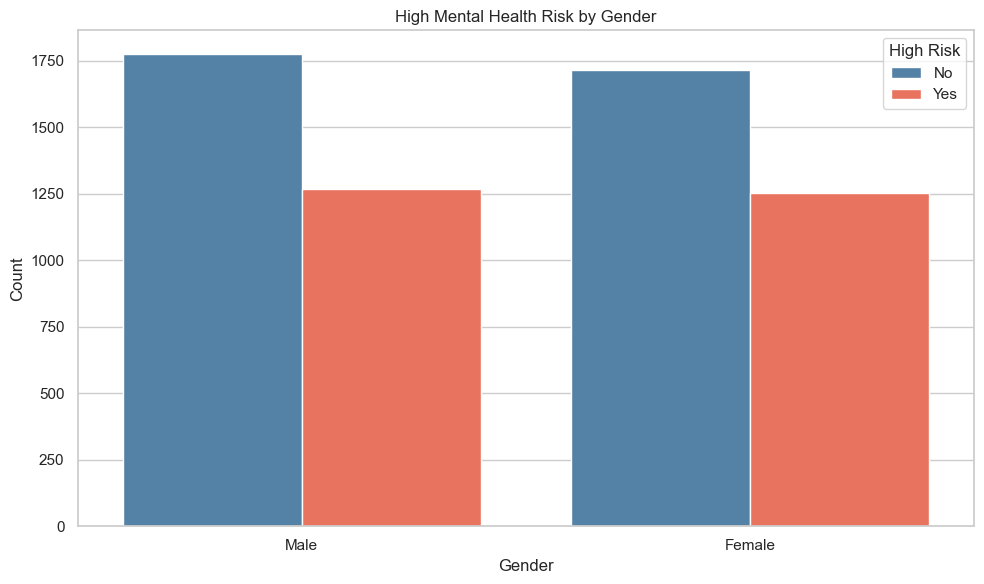

In [19]:
# 3. Countplot — Gender vs High Risk — same as teacher's sex countplot
plt.figure(figsize=(10, 6))
sns.countplot(x='Gender', hue='High_Risk', data=df,
              palette=['steelblue', 'tomato'])
plt.title('High Mental Health Risk by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='High Risk', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

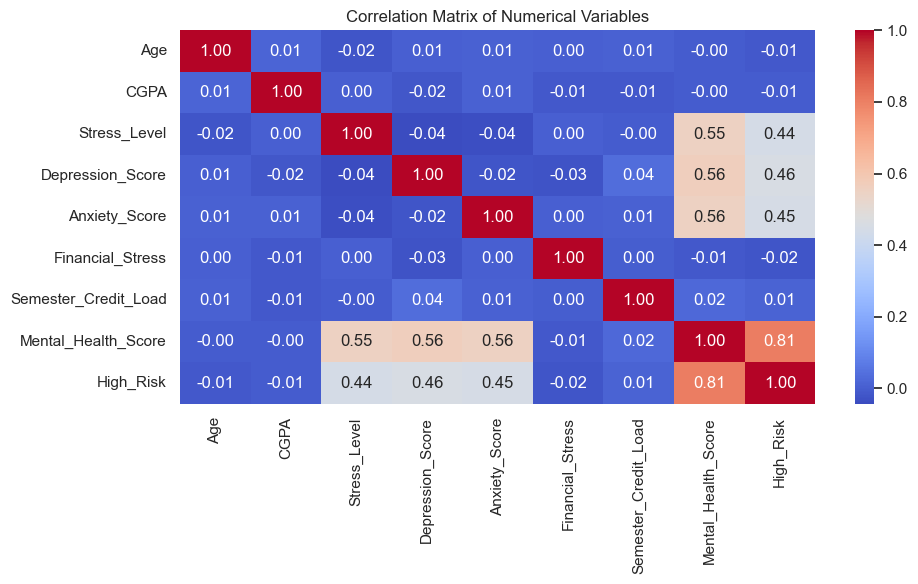

In [20]:
# 4. Correlation heatmap — same as teacher's reference
plt.figure(figsize=(10, 6))
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

In [21]:
# Print correlation matrix values
print(correlation_matrix)

                           Age      CGPA  Stress_Level  Depression_Score  \
Age                   1.000000  0.014930     -0.022014          0.005598   
CGPA                  0.014930  1.000000      0.003065         -0.018553   
Stress_Level         -0.022014  0.003065      1.000000         -0.043190   
Depression_Score      0.005598 -0.018553     -0.043190          1.000000   
Anxiety_Score         0.009171  0.008746     -0.036014         -0.020727   
Financial_Stress      0.001760 -0.011563      0.002603         -0.025076   
Semester_Credit_Load  0.008076 -0.014140     -0.004192          0.035818   
Mental_Health_Score  -0.004449 -0.004172      0.553684          0.563993   
High_Risk            -0.014141 -0.005491      0.444142          0.456637   

                      Anxiety_Score  Financial_Stress  Semester_Credit_Load  \
Age                        0.009171          0.001760              0.008076   
CGPA                       0.008746         -0.011563             -0.014140   
St

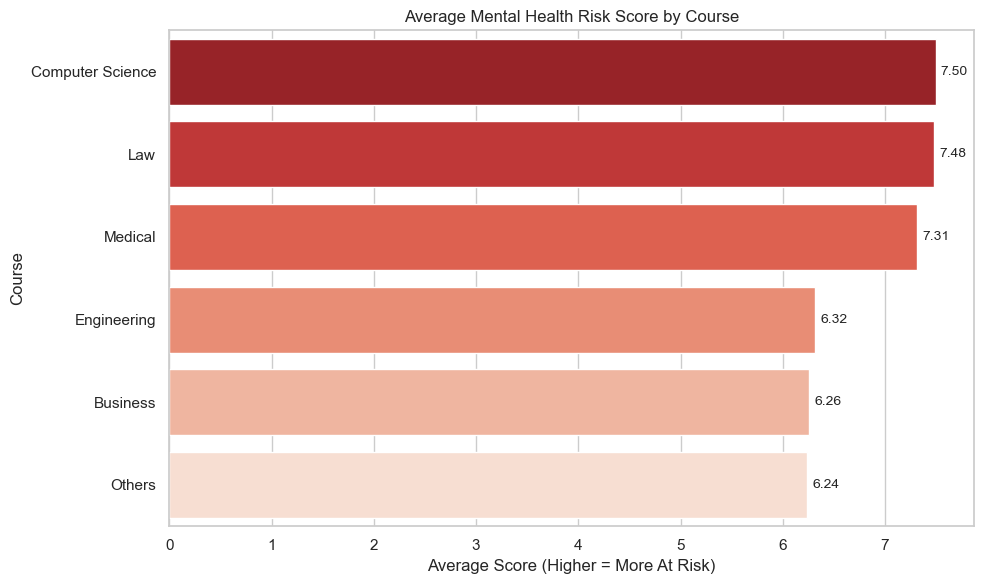

In [22]:
# 5. Average Mental Health Score by Course
plt.figure(figsize=(10, 6))
course_mh = df.groupby('Course')['Mental_Health_Score'].mean().sort_values(ascending=False)
sns.barplot(x=course_mh.values, y=course_mh.index, palette='Reds_r')
plt.title('Average Mental Health Risk Score by Course')
plt.xlabel('Average Score (Higher = More At Risk)')
plt.ylabel('Course')
for i, v in enumerate(course_mh.values):
    plt.text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

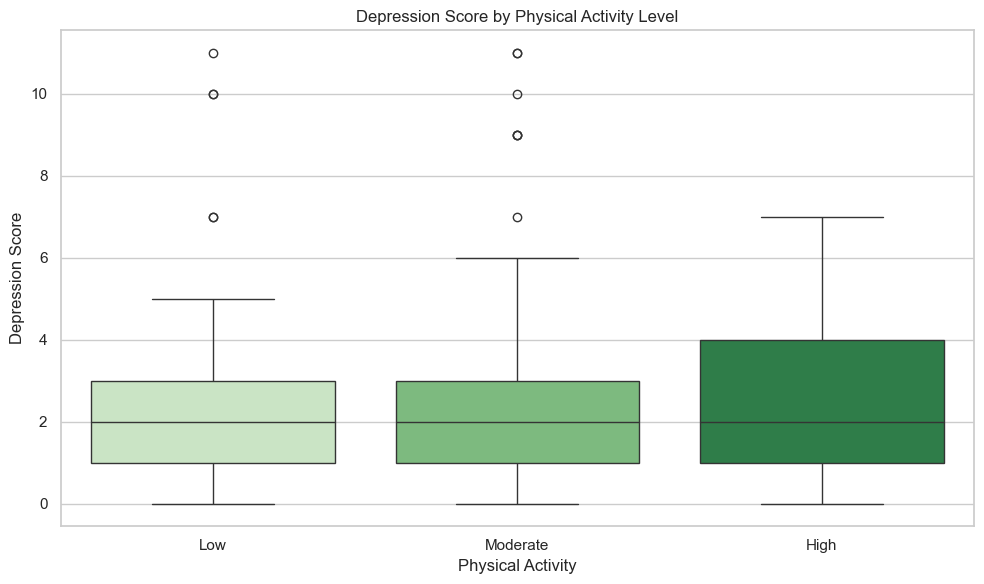

In [23]:
# 6. Depression Score by Physical Activity
plt.figure(figsize=(10, 6))
sns.boxplot(x='Physical_Activity', y='Depression_Score', data=df,
            order=['Low', 'Moderate', 'High'], palette='Greens')
plt.title('Depression Score by Physical Activity Level')
plt.xlabel('Physical Activity')
plt.ylabel('Depression Score')
plt.tight_layout()
plt.show()

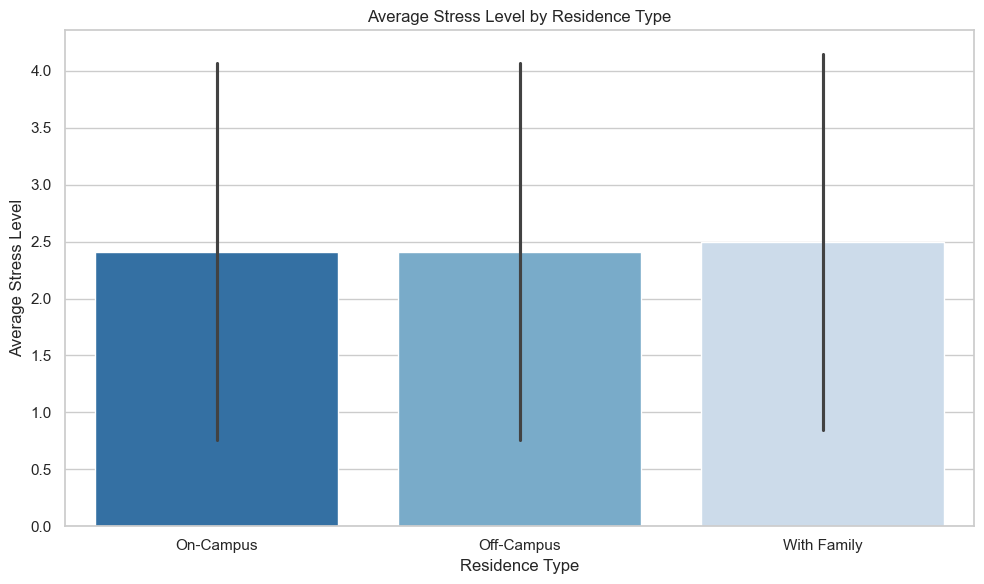

In [24]:
# 7. Stress Level by Residence Type
plt.figure(figsize=(10, 6))
sns.barplot(x='Residence_Type', y='Stress_Level', data=df,
            palette='Blues_r', errorbar='sd')
plt.title('Average Stress Level by Residence Type')
plt.xlabel('Residence Type')
plt.ylabel('Average Stress Level')
plt.tight_layout()
plt.show()

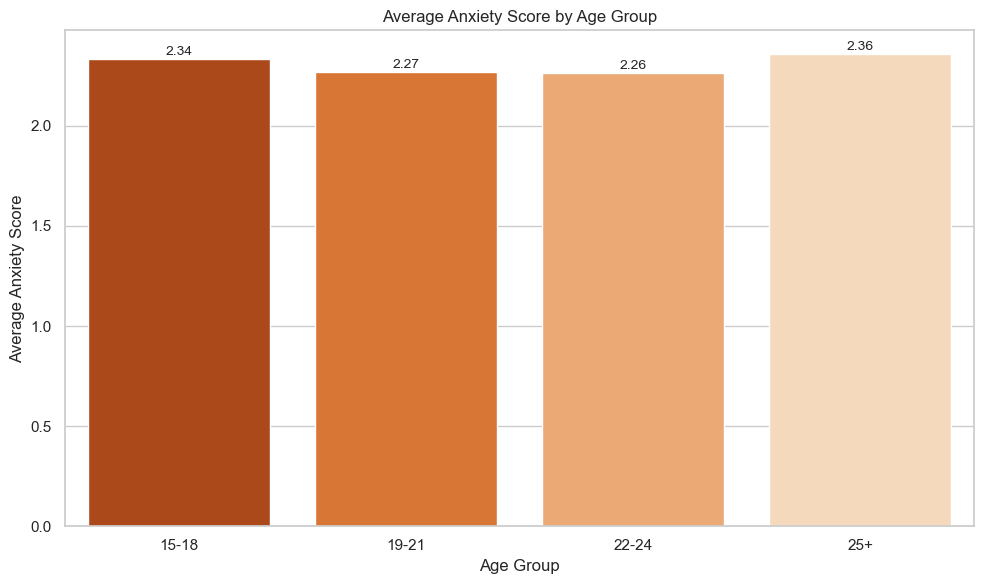

In [25]:
# 8. Anxiety Score by Age Group
plt.figure(figsize=(10, 6))
age_anxiety = df.groupby('Age_Group', observed=True)['Anxiety_Score'].mean().reset_index()
sns.barplot(x='Age_Group', y='Anxiety_Score', data=age_anxiety, palette='Oranges_r')
plt.title('Average Anxiety Score by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Anxiety Score')
for i, row in age_anxiety.iterrows():
    plt.text(i, row['Anxiety_Score'] + 0.02, f"{row['Anxiety_Score']:.2f}",
             ha='center', fontsize=10)
plt.tight_layout()
plt.show()

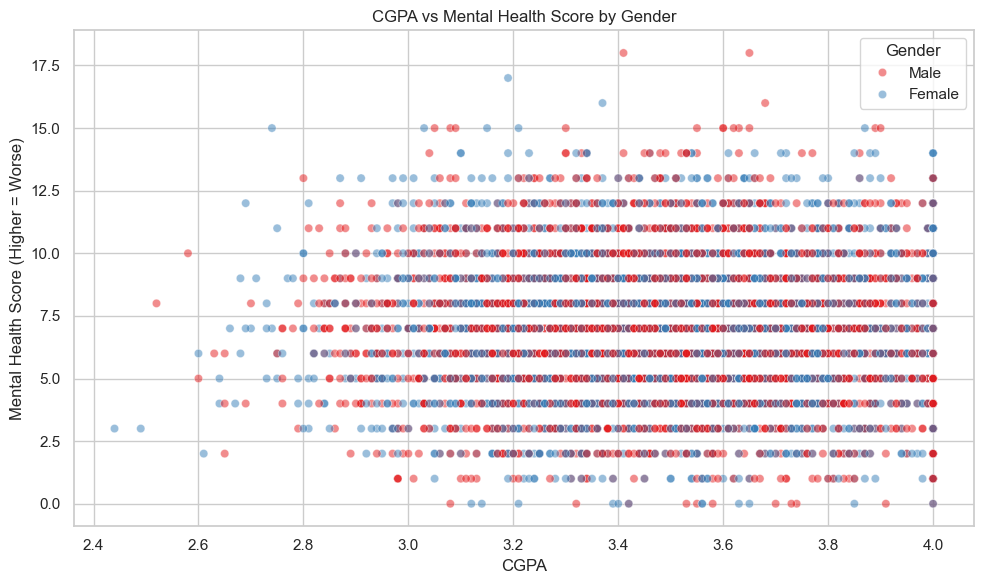

In [26]:
# 9. Scatter plot — CGPA vs Mental Health Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CGPA', y='Mental_Health_Score', hue='Gender',
                data=df, alpha=0.5, palette='Set1')
plt.title('CGPA vs Mental Health Score by Gender')
plt.xlabel('CGPA')
plt.ylabel('Mental Health Score (Higher = Worse)')
plt.tight_layout()
plt.show()

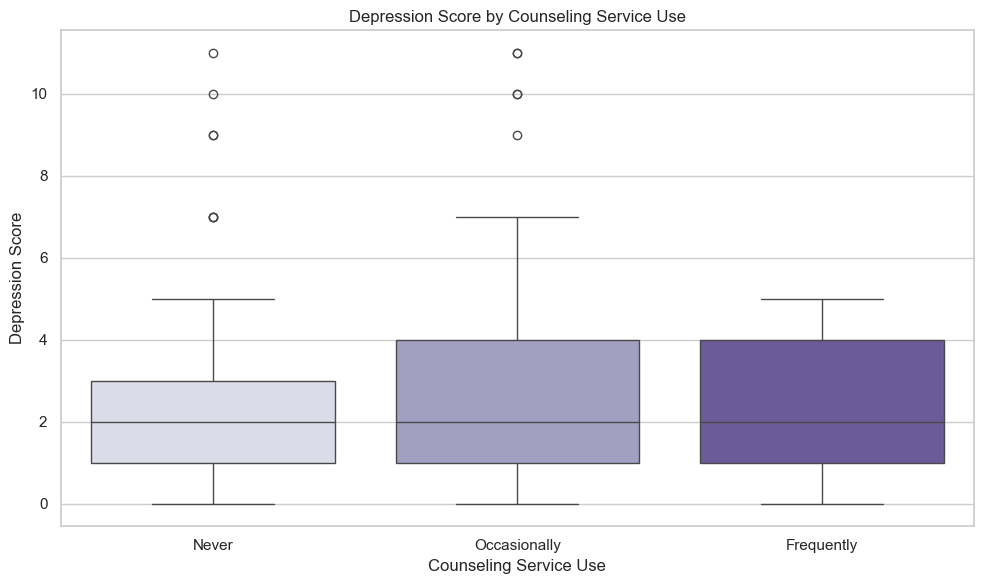

In [27]:
# 10. Counseling Service Use vs Depression Score
plt.figure(figsize=(10, 6))
sns.boxplot(x='Counseling_Service_Use', y='Depression_Score', data=df,
            order=['Never', 'Occasionally', 'Frequently'], palette='Purples')
plt.title('Depression Score by Counseling Service Use')
plt.xlabel('Counseling Service Use')
plt.ylabel('Depression Score')
plt.tight_layout()
plt.show()

## Step 8 — Statistical Analysis (Hypothesis Tests)

In [28]:
# T-Test: Do male and female students have different stress levels?
# H0: Mean stress level is same for Male and Female
# H1: Mean stress level is different

male_stress   = df[df['Gender'] == 'Male']['Stress_Level']
female_stress = df[df['Gender'] == 'Female']['Stress_Level']

t_stat, p_val = stats.ttest_ind(male_stress, female_stress)

print('=== T-TEST: Stress Level — Male vs Female ===')
print(f'Male   — Mean: {male_stress.mean():.2f}  |  Std: {male_stress.std():.2f}')
print(f'Female — Mean: {female_stress.mean():.2f}  |  Std: {female_stress.std():.2f}')
print(f'T-statistic : {t_stat:.4f}')
print(f'P-value     : {p_val:.4f}')
if p_val < 0.05:
    print('Result: REJECT H0 — Significant difference in stress between genders (p < 0.05)')
else:
    print('Result: FAIL TO REJECT H0 — No significant difference (p >= 0.05)')

=== T-TEST: Stress Level — Male vs Female ===
Male   — Mean: 2.44  |  Std: 1.64
Female — Mean: 2.42  |  Std: 1.67
T-statistic : 0.4046
P-value     : 0.6858
Result: FAIL TO REJECT H0 — No significant difference (p >= 0.05)


In [29]:
# ANOVA: Is depression score different across courses?
# H0: All courses have the same mean depression score
# H1: At least one course is different

groups = [
    df[df['Course'] == c]['Depression_Score'].values
    for c in df['Course'].unique()
]

f_stat, p_val_anova = stats.f_oneway(*groups)

print('=== ANOVA: Depression Score Across Courses ===')
print(f'F-statistic : {f_stat:.4f}')
print(f'P-value     : {p_val_anova:.4f}')
if p_val_anova < 0.05:
    print('Result: REJECT H0 — Depression score differs significantly across courses (p < 0.05)')
else:
    print('Result: FAIL TO REJECT H0 — No significant difference across courses')

=== ANOVA: Depression Score Across Courses ===
F-statistic : 89.7549
P-value     : 0.0000
Result: REJECT H0 — Depression score differs significantly across courses (p < 0.05)


In [30]:
# Chi-Square: Is High Risk associated with Family History of mental illness?
# H0: High Risk and Family History are independent
# H1: There is a relationship between them

contingency = pd.crosstab(df['High_Risk'], df['Family_History'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

print('=== CHI-SQUARE TEST: High Risk vs Family History ===')
print('Contingency Table:')
print(contingency)
print(f'\nChi2 statistic    : {chi2:.4f}')
print(f'Degrees of freedom: {dof}')
print(f'P-value           : {p_chi:.4f}')
if p_chi < 0.05:
    print('Result: REJECT H0 — Family History IS associated with High Risk (p < 0.05)')
else:
    print('Result: FAIL TO REJECT H0 — No significant association')

=== CHI-SQUARE TEST: High Risk vs Family History ===
Contingency Table:
Family_History    No   Yes
High_Risk                 
0               2443  1049
1               1768   753

Chi2 statistic    : 0.0131
Degrees of freedom: 1
P-value           : 0.9090
Result: FAIL TO REJECT H0 — No significant association


## Step 9 — Cache Data for Dashboard

In [31]:
# Cache data to improve dashboard performance — same as teacher's reference
if 'data' not in pn.state.cache.keys():
    pn.state.cache['data'] = df.copy()
else:
    df = pn.state.cache['data']

print(f'Data cached. Total students: {len(df):,}')

Data cached. Total students: 6,013


## Step 10 — Panel Widgets (Dashboard Filters)

In [32]:
# Stress Level slider — same as teacher's year slider
stress_slider = pn.widgets.IntSlider(
    name='Max Stress Level',
    start=0, end=10, step=1, value=10
)
stress_slider

IntSlider(end=10, name='Max Stress Level', value=10)

In [33]:
# Radio buttons for mental health metric — same as teacher's RadioButtonGroup
yaxis_metric = pn.widgets.RadioButtonGroup(
    name='Y axis',
    options=['Stress_Level', 'Depression_Score', 'Anxiety_Score'],
    button_type='success'
)
yaxis_metric

RadioButtonGroup(button_type='success', name='Y axis', options=['Stress_Level', ...], value='Stress_Level')

In [34]:
# Radio buttons for bar chart breakdown
yaxis_bar = pn.widgets.RadioButtonGroup(
    name='Bar Metric',
    options=['Stress_Level', 'Depression_Score', 'Anxiety_Score'],
    button_type='success'
)
yaxis_bar

RadioButtonGroup(button_type='success', name='Bar Metric', options=['Stress_Level', ...], value='Stress_Level')

## Step 11 — Interactive Pipelines (hvplot)

In [35]:
# Make dataframe interactive — same as teacher's reference
idf = df.interactive()

In [36]:
# Chart 1: Mental health metric by Course (line chart — like teacher's CO2 by continent)
mh_pipeline = (
    idf[
        idf.Stress_Level <= stress_slider
    ]
    .groupby(['Course'])[yaxis_metric].mean()
    .to_frame()
    .reset_index()
    .sort_values(by=yaxis_metric)
    .reset_index(drop=True)
)

mh_pipeline

In [43]:
mh_plot = mh_pipeline.hvplot(
    x='Course',
    y=yaxis_metric,
    kind='bar',
    line_width=2,
    title='Average Mental Health Score by Course',
    height=350
)
mh_plot

In [44]:
# Table — same as teacher's Tabulator
mh_table = mh_pipeline.pipe(
    pn.widgets.Tabulator,
    pagination='remote',
    page_size=10,
    sizing_mode='stretch_width'
)
mh_table

In [45]:
# Chart 2: CGPA vs Mental Health Score scatter — like teacher's CO2 vs GDP scatter
scatter_pipeline = (
    idf[
        idf.Stress_Level <= stress_slider
    ]
    .groupby(['CGPA_Category', 'Course'])[yaxis_metric].mean()
    .to_frame()
    .reset_index()
)

scatter_plot = scatter_pipeline.hvplot(
    x='CGPA_Category', y=yaxis_metric,
    by='Course',
    size=80, kind='scatter',
    alpha=0.7, legend=False,
    height=500, width=500,
    title='CGPA Category vs Mental Health Score'
)
scatter_plot

In [46]:
# Chart 3: Bar chart — metric by Residence Type — like teacher's CO2 source bar
residence_pipeline = (
    idf[
        idf.Stress_Level <= stress_slider
    ]
    .groupby(['Residence_Type'])[yaxis_bar].mean()
    .to_frame()
    .reset_index()
    .sort_values(by=yaxis_bar)
    .reset_index(drop=True)
)

residence_bar = residence_pipeline.hvplot(
    kind='bar',
    x='Residence_Type',
    y=yaxis_bar,
    title='Average Score by Residence Type'
)
residence_bar

## Step 12 — Assemble Full Dashboard (FastListTemplate)

In [47]:
# KPI values for sidebar
total_students   = len(df)
high_risk_count  = int(df['High_Risk'].sum())
high_risk_pct    = round(df['High_Risk'].mean() * 100, 1)
avg_stress       = round(df['Stress_Level'].mean(), 2)
avg_depression   = round(df['Depression_Score'].mean(), 2)

# Layout using FastListTemplate — exact same structure as teacher's reference
template = pn.template.FastListTemplate(
    title='Student Mental Health Analysis Dashboard',
    sidebar=[
        pn.pane.Markdown('# Mental Health Dashboard'),
        pn.pane.Markdown(
            f'**Total Students:** {total_students:,}  \n'
            f'**High Risk Students:** {high_risk_count:,}  \n'
            f'**High Risk Rate:** {high_risk_pct}%  \n'
            f'**Avg Stress Level:** {avg_stress}  \n'
            f'**Avg Depression Score:** {avg_depression}'
        ),
        pn.pane.Markdown('## Settings'),
        stress_slider,
        pn.pane.Markdown('**Chart Metric**'),
        yaxis_metric,
        pn.pane.Markdown('**Bar Chart Metric**'),
        yaxis_bar,
    ],
    main=[
        pn.Row(
            pn.Column(
                yaxis_metric,
                mh_plot.panel(width=700),
                margin=(0, 25)
            ),
            mh_table.panel(width=500)
        ),
        pn.Row(
            pn.Column(
                scatter_plot.panel(width=600),
                margin=(0, 25)
            ),
            pn.Column(
                yaxis_bar,
                residence_bar.panel(width=600)
            )
        )
    ],
    accent_base_color='#5C6BC0',
    header_background='#5C6BC0',
)

template.show()
template.servable()

Launching server at http://localhost:57324


FastListTemplate
    [js_area] HTML(None, height=0, margin=0, sizing_mode='fixed', width=0)
    [actions] TemplateActions()
    [browser_info] BrowserInfo(dark_mode=False, device_pixel_ratio=2, language='en-GB', timezone='Asia/Calcutta', timezone_offset=-330, webdriver=False, webgl=True)
    [busy_indicator] LoadingSpinner(height=20, width=20)
    [main-6244952656] Row
        [0] Column(margin=(0, 25))
            [0] RadioButtonGroup(button_type='success', name='Y axis', options=['Stress_Level', ...], value='Stress_Level')
            [1] ParamFunction(function, _pane=HoloViews, defer_load=False, width=700)
        [1] ParamFunction(function, _pane=Tabulator, defer_load=False, width=500)
    [main-6245437904] Row
        [0] Column(margin=(0, 25))
            [0] ParamFunction(function, _pane=HoloViews, defer_load=False, width=600)
        [1] Column
            [0] RadioButtonGroup(button_type='success', name='Bar Metric', options=['Stress_Level', ...], value='Stress_Level')
            [1] ParamFunction(function, _pane=HoloViews, defer_load=False, width=600)
    [nav-6244663952] Markdown(str)
    [nav-6243376112] Markdown(str)
    [nav-6243376656] Markdown(str)
    [nav-6092192272] IntSlider(end=10, name='Max Stress Level', value=10)
    [nav-6372948304] Markdown(str)
    [nav-6092192608] RadioButtonGroup(button_type='success', name='Y axis', options=['Stress_Level', ...], value='Stress_Level')
    [nav-6372947792] Markdown(str)
    [nav-6255263824] RadioButtonGroup(button_type='success', name='Bar Metric', options=['Stress_Level', ...], value='Stress_Level')

2026-04-23 01:58:45,538 ERROR: panel.reactive - Callback failed for object named 'Bar Metric' changing property {'value': 'Depression_Score'} 
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/panel/reactive.py", line 476, in _process_events
    self.param.update(**self_params)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/param/parameterized.py", line 2787, in update
    restore = dict(self_._update(arg, **kwargs))
                   ~~~~~~~~~~~~~^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/param/parameterized.py", line 2820, in _update
    self_._batch_call_watchers()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/opt/anaconda3/lib/python3.13/site-packages/param/parameterized.py", line 3037, in _batch_call_watchers
    self_._execute_watcher(watcher, events)
    ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/param/parameterized.py", line 2999,

## Step 13 — How to Run

Run this in your terminal to launch the dashboard:

```bash
panel serve Student_Mental_Health_Dashboard.ipynb --show
```

Or inside Jupyter — run all cells, `template.show()` opens it automatically.